In [1]:
from myutils import *
from scipy.stats import ortho_group
from scipy.optimize import minimize
from tqdm import tqdm

from scipy.integrate import quad

In [ ]:
class Psi:
    def __init__(self, x, mu, sigma):
        self.x = x
        self.mu = mu
        self.sigma = sigma

        psi_vec = Psi.func(x, mu, sigma)
        self.psi_vec = psi_vec / np.linalg.norm(psi_vec)

        psi_prime_vec = Psi.prime_func(x, mu, sigma)
        self.psi_prime_vec = psi_prime_vec / np.linalg.norm(psi_prime_vec)

        self.basis = np.column_stack([self.psi_vec, self.psi_prime_vec])


    @staticmethod
    def func(x, mu, sigma):
        return np.exp(-(x-mu)**2 / (4*sigma**2)) / (2*np.pi*sigma**2)**.25


    @staticmethod
    def prime_func(x, mu, sigma):
        prefactor = 1 / (2 * (2*np.pi)**.25)
        exp_part = np.exp(-(x-mu)**2 / (4*sigma**2))
        power_part = (1 / sigma**2)**(5 / 4)
        return prefactor * exp_part * (x - mu) * power_part



In [3]:
class POVM:
    def __init__(self, psi: Psi, U=None):
        if U is None:
            U = ortho_group.rvs(dim=2)

        M = psi.basis @ U
        self.E1, self.E2 = np.outer(M[:, 0].conj(), M[:, 0]), np.outer(M[:, 1].conj(), M[:, 1])
        

In [40]:
class Measure:
    def __init__(self, psi: Psi, povm: POVM):
        self.psi = psi
        self.povm = povm

        self.p1 = np.real(psi.psi_vec.conj().T @ povm.E1 @ psi.psi_vec)
        self.p2 = np.real(psi.psi_vec.conj().T @ povm.E2 @ psi.psi_vec)

    
    def prob(self, theta):
        psi_theta = Psi(self.psi.x, theta, self.psi.sigma)
        m = Measure(psi_theta, self.povm)
        return np.array([m.p1, m.p2])
    

    def cfi(self, theta, b=0, eps=1e-8):
        dp = (self.prob(theta + eps) - self.prob(theta - eps)) / (2*eps)
        return dp**2 / (b + np.clip(self.prob(theta), 1e-10, np.inf))


    def gen(self, photons: int, noise: int, repeat: int):
        self.photons = photons
        self.noise = noise
        self.repeat = repeat
        outcomes = []
        for _ in range(repeat):
            data = np.histogram(np.random.uniform(0, 1, np.random.poisson(photons)), [0, self.p1, self.p1 + self.p2])[0] + \
                   np.random.poisson(noise, 2)
            outcomes.append(data)
        self.outcomes = np.array(outcomes)
        return self.outcomes


    def est(self, retry=5):
        def mle(data):
            def nll(theta):
                psi = Psi(self.psi.x, theta, self.psi.sigma)
                m = Measure(psi, self.povm)

                Lam1 = m.p1 * self.photons + self.noise
                Lam2 = m.p2 * self.photons + self.noise
                Lam = np.array([Lam1, Lam2])

                return - data @ np.log(Lam).T + np.sum(Lam)

            for _ in range(retry):
                opt = minimize(nll, x0=np.random.uniform(self.psi.x.min(), self.psi.x.max(), 1))
                if opt.success:
                    break

            if opt.success:
                return opt.x.item()
            else:
                return np.nan

        result = [] 
        for i in range(self.repeat):
            result.append(mle(self.outcomes[i]))
        self.result = np.array(result)
        return self.result



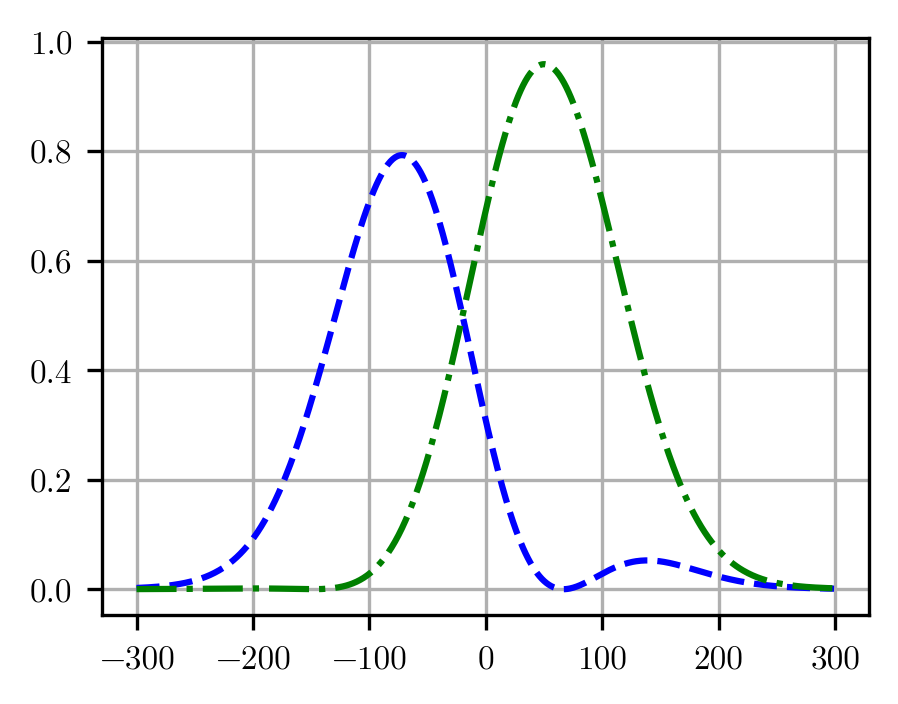

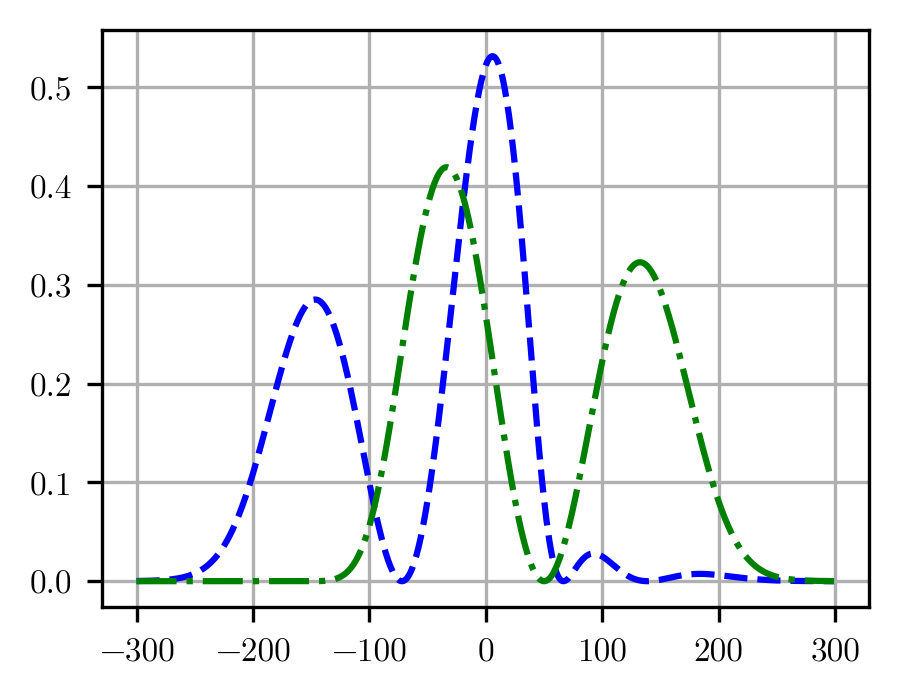

In [42]:
psi = Psi(np.arange(-300, 300, 1), 0, 50)
m = Measure(psi, POVM(psi))
plot(np.arange(-300, 300), [m.prob(theta)[0] for theta in np.arange(-300, 300)])
plot(np.arange(-300, 300), [m.prob(theta)[1] for theta in np.arange(-300, 300)])
plt.show()

plot(np.arange(-300, 300), [m.cfi(theta, b=0.1)[0] * 50**2 for theta in np.arange(-300, 300)])
plot(np.arange(-300, 300), [m.cfi(theta, b=0.1)[1] * 50**2 for theta in np.arange(-300, 300)])

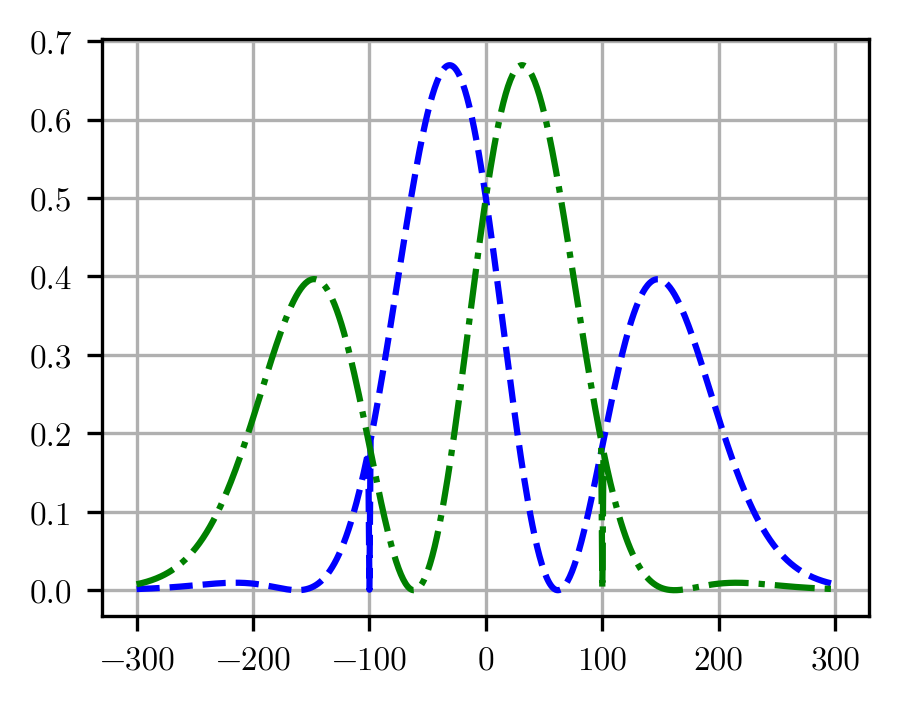

In [26]:
psi = Psi(np.arange(-300, 300, 1), 0, 50)
m = Measure(psi, POVM(psi, U=np.array([[1, 1], [1, -1]])/2**.5))
plot(np.arange(-300, 300), [m.cfi(theta)[0] * 50**2 for theta in np.arange(-300, 300)])
plot(np.arange(-300, 300), [m.cfi(theta)[1] * 50**2 for theta in np.arange(-300, 300)])

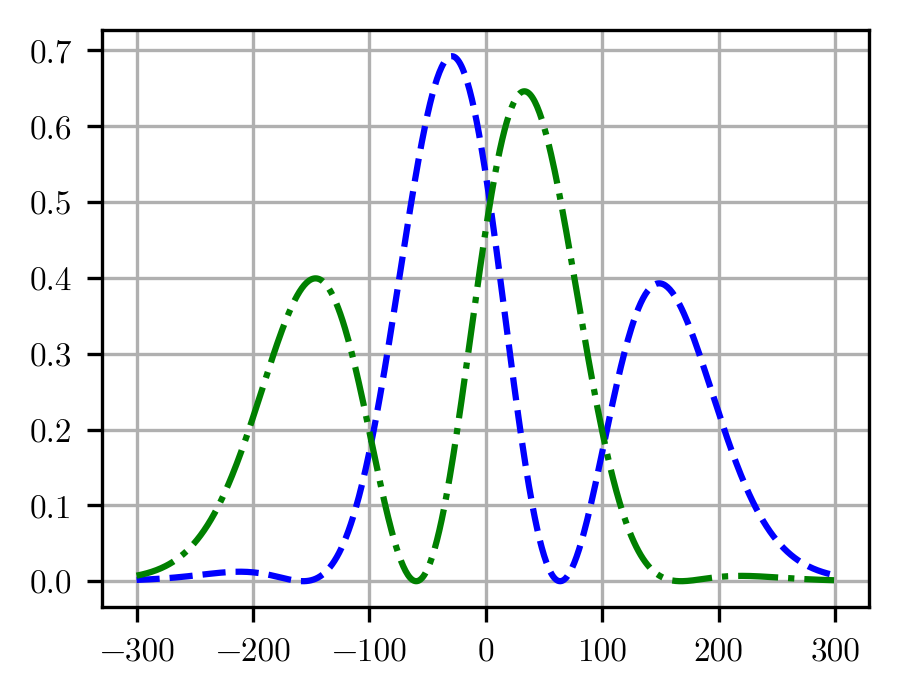

In [37]:
psi = Psi(np.arange(-300, 300, 1), 0, 50)
m = Measure(psi, POVM(psi))
plot(np.arange(-300, 300), [m.cfi(theta)[0] * 50**2 for theta in np.arange(-300, 300)])
plot(np.arange(-300, 300), [m.cfi(theta)[1] * 50**2 for theta in np.arange(-300, 300)])

In [43]:
psi = Psi(np.arange(-300, 300, 1), 0, 50)

sim = []
for _ in tqdm(range(1000)):
    m = Measure(psi, POVM(psi))
    sim.append(np.sum(m.cfi(0, b=0.1)) * 50**2)

100%|██████████| 1000/1000 [00:06<00:00, 154.88it/s]


In [ ]:
psi = Psi(np.arange(-300, 300, 1), 0, 50)
sim = []
for b in np.linspace(0, 0.1, 30):
    for _ in range(100):
        m = Measure(psi, POVM(psi))
        sim.append([b, np.sum(m.cfi(0, b)) * 50**2])
sim = np.array(sim)

In [62]:
np.array(sim)[:, 0]

array([0. , 0. , 0. , ..., 0.1, 0.1, 0.1])

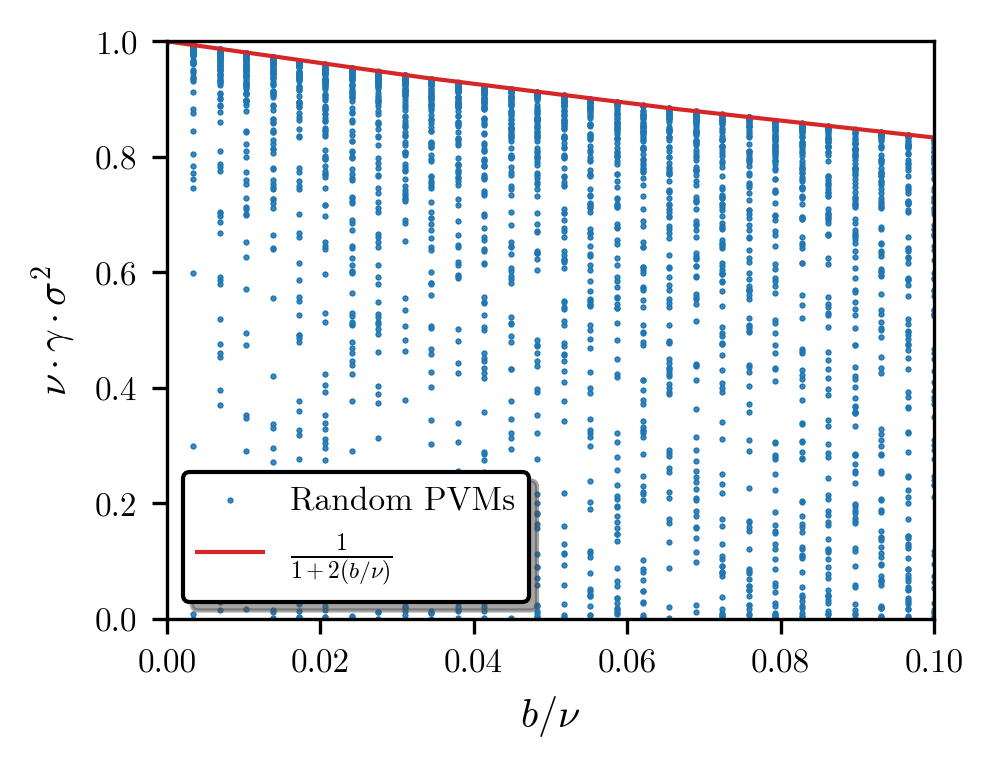

In [ ]:
plt.scatter(np.array(sim)[:, 0], np.array(sim)[:, 1], c='tab:blue', marker='.', s=1, label='Random PVMs')

plt.grid(False)
plt.ylim(0, 1)
plt.xlim(0, 0.1)

plt.plot(np.linspace(0, 0.1, 4), 1 / (1 + 2*np.linspace(0, 0.1, 4)), color='tab:red', linewidth=1, linestyle='-',
         label=r'$\frac{1}{1+2(b / \nu)}$')

plt.ylabel(r'$\nu\cdot\gamma \cdot \sigma^{2}$')
plt.xlabel(r'$b/\nu$')
plt.legend(fancybox=True, shadow=True)
plt.show()

In [15]:
psi = Psi(np.arange(-300, 300, 1), 0, 50)

sim = []
for _ in tqdm(range(1)):
    m = Measure(psi, POVM(psi, U=np.array([[1, 1], [1, -1]])/2**.5))
    m.gen(100, 0, 100)
    m.est()

    sim.append(np.nanvar(m.result, ddof=1) * 100 / 50**2)

100%|██████████| 1/1 [00:01<00:00,  1.40s/it]


In [16]:
sim

[467.6200288721893]

In [36]:
(np.array([[1, 1], [1, -1]])/2**.5).T @ (np.array([[1, 1], [1, -1]])/2**.5)

array([[ 1.00000000e+00, -2.23711432e-17],
       [-2.23711432e-17,  1.00000000e+00]])

In [ ]:

# plot(psi.psi_prime_vec)

In [107]:
def p(theta):
    psi0 = Psi(np.arange(-300, 300, 1), 0, 50)
    povm = POVM(psi0, np.array([[1, 1], [1, -1]])/2**.5)

    psi = Psi(np.arange(-300, 300, 1), theta, 50)
    m = Measure(psi, povm)
    return m.p1

In [97]:
def p(theta):
    psi  = Psi(np.arange(-300, 300, 1), theta, 50)
    psi0 = Psi(np.arange(-300, 300, 1), 0, 50)


    # M1 = (psi0.psi_vec + psi.psi_prime_vec) / 2**.5
    # M2 = (psi0.psi_vec - psi.psi_prime_vec) / 2**.5
    # E1 = np.outer(M1.conj(), M1)
    # E2 = np.outer(M2.conj(), M2)

    # return np.abs(psi.psi_vec.T @ psi0.psi_vec - psi.psi_vec.T @ psi0.psi_prime_vec)**2 / 2

    U = np.array([[1, 1], [1, -1]]) / 2**.5
    bais = np.column_stack([psi0.psi_vec, psi0.psi_prime_vec])
    M = bais @ U
    E1 = np.outer(M[:, 0].conj().T, M[:, 0])
    E2 = np.outer(M[:, 1].conj().T, M[:, 1])

    return psi.psi_vec.conj().T @ E1 @ psi.psi_vec


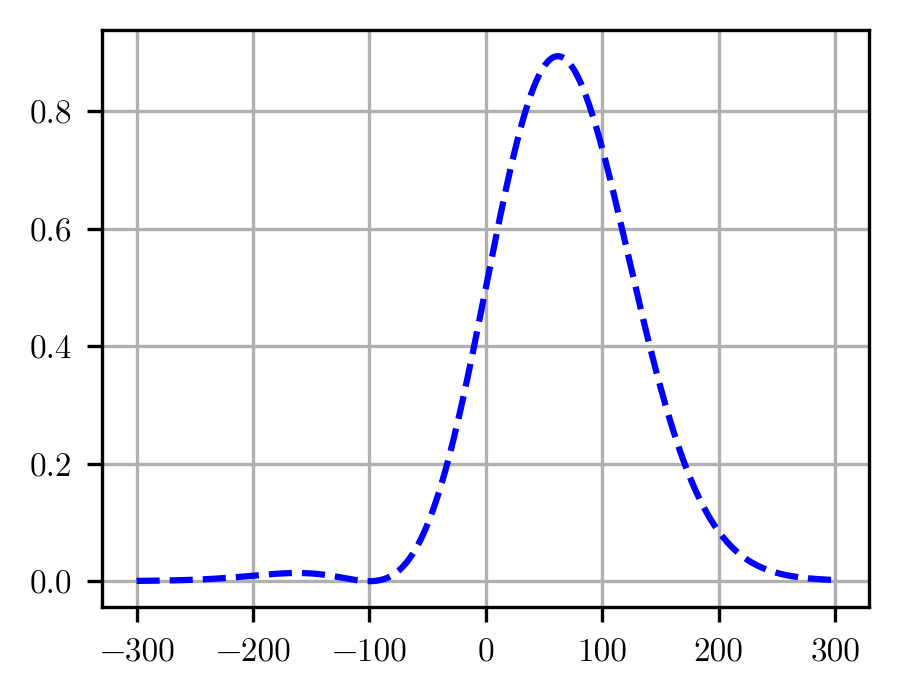

In [109]:
plot(np.arange(-300, 300, 1), [p(i) for i in np.arange(-300, 300, 1)])

In [69]:
psi0 = Psi(np.arange(-300, 300, 1), 0, 50)    
M1 = (psi0.psi_vec + psi.psi_prime_vec) / 2**.5
M2 = (psi0.psi_vec - psi.psi_prime_vec) / 2**.5
E1 = np.outer(M1.conj(), M1)
E2 = np.outer(M2.conj(), M2)

In [73]:
U = np.array([[1, 1], [1, -1]]) / 2**.5

In [87]:
bais = np.column_stack([psi0.psi_vec, psi0.psi_prime_vec])
mat = bais @ U

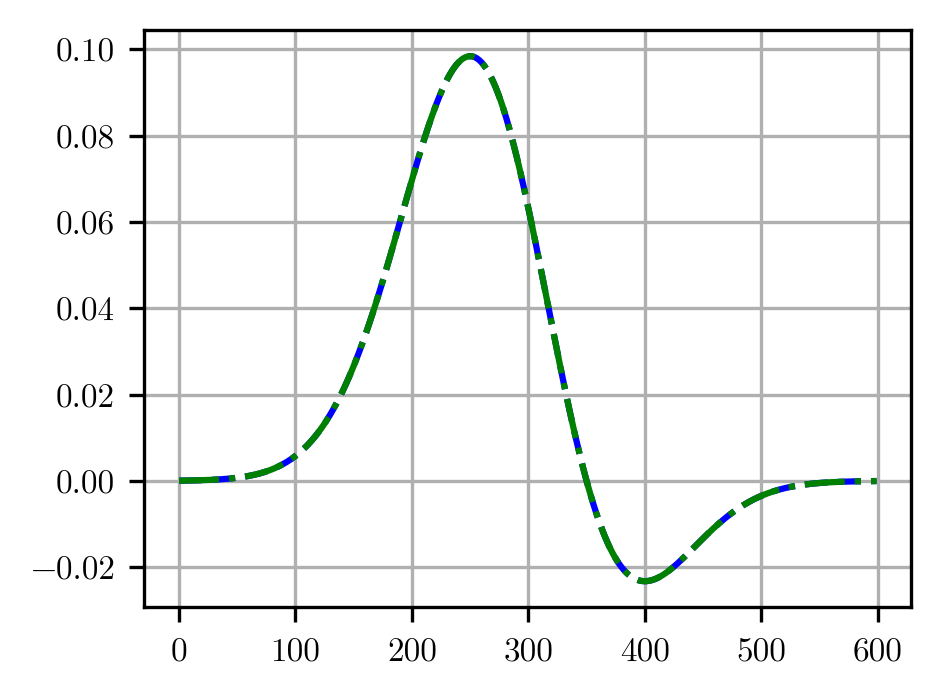

In [92]:
plot(mat[:, 1])
plot((psi0.psi_vec - psi0.psi_prime_vec) / 2**.5)

In [94]:
E1 = np.outer(mat[:, 0].conj(), mat[:, 0])
E2 = np.outer(mat[:, 1].conj(), mat[:, 1])

In [ ]:
lambda theta: Psi(np.arange(-300, 300, 1), 0, 50)

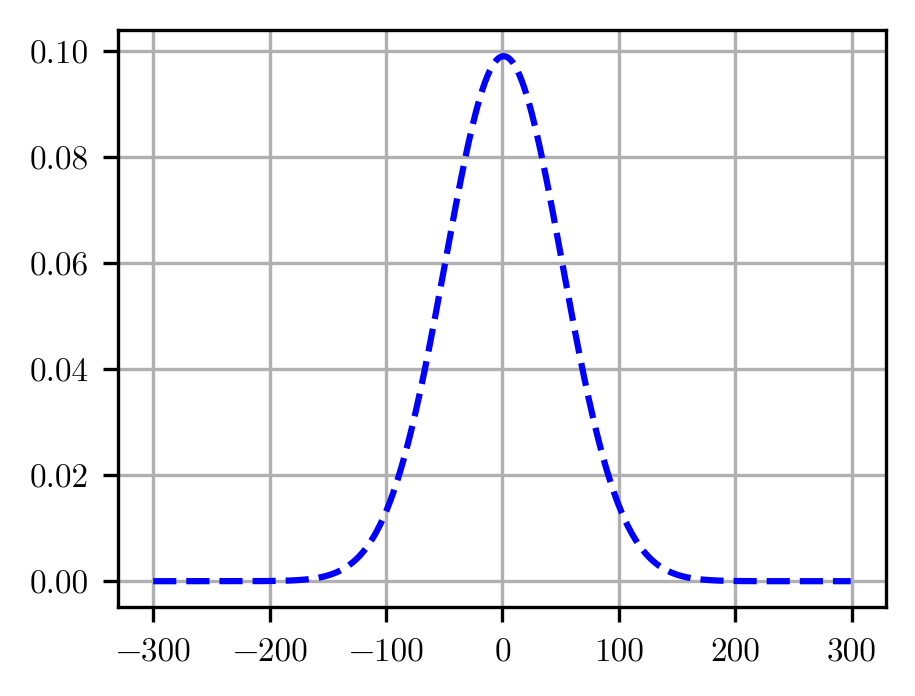

In [61]:
plot(np.arange(-300, 300, 1), [p(i)[0] for i in np.arange(-300, 300, 1)])
# plot(np.arange(-300, 300, 1), [p(i)[1] for i in np.arange(-300, 300, 1)])

In [20]:
np.var(m.result) * 100 / 100**2

21.058652043898782

In [23]:
m.result.mean()

51.80246418313716

In [14]:
np.mean(sim)

19.08128056522219

In [16]:
np.mean(sim)

21.20194513319615

In [17]:
21.2 / 19

1.1157894736842104